
# 02 · Testing the maximum Colab input size for BOA

This notebook isolates the second supervisor-requested task:

> **Testing max size of Colab input data**

It compares the two input paths discussed in the meeting:

1. **Whole-file eager loading** — reproduce the preparation path used in notebook 01:
   `np.fromfile(..., dtype=np.uint8).tobytes()`, followed by a float32 reshape.
2. **Memory-mapped/chunked reading** — scan a much larger file in bounded-size blocks without
   holding the complete file in host RAM.

The two results answer different questions:

- the eager test gives a runtime-specific RAM boundary for whole-file preparation;
- the streaming test gives only a verified lower bound for stream-readable input size. It is **not**
  a universal BOA compression maximum, because a full compression run is also limited by local
  disk, output space, throughput and Colab session duration.

The notebook does **not** rerun training, compression or CodeCarbon. It optionally reads
`results/boa_metrics.json` produced by notebook 01 so that the measured BOA compression throughput
can be used to estimate how long a larger full compression run would take.



## 1 · Shared project folder and optional notebook-01 result

The three notebooks use the same persistent Google Drive folder:

```text
MyDrive/BOA_carbon_project/
├── results/
├── artifacts/
└── plots/
```

Only small result files are written to Drive. The temporary multi-gigabyte benchmark input stays on
Colab's local disk and is deleted at the end unless `KEEP_TILED_INPUT=True`.


In [1]:

from pathlib import Path
import json
import os
import sys

IN_COLAB = "google.colab" in sys.modules
SAVE_TO_GOOGLE_DRIVE = True

if IN_COLAB and SAVE_TO_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/BOA_carbon_project")
else:
    PROJECT_ROOT = Path.cwd() / "BOA_carbon_project"

RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = PROJECT_ROOT / "plots"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_01_METRICS_PATH = RESULTS_DIR / "boa_metrics.json"
BOA_METRICS = None

if NOTEBOOK_01_METRICS_PATH.exists():
    with NOTEBOOK_01_METRICS_PATH.open("r", encoding="utf-8") as handle:
        BOA_METRICS = json.load(handle)
    print("Loaded notebook-01 measurements:", NOTEBOOK_01_METRICS_PATH)
    print(f"Measured BOA input: {BOA_METRICS.get('input_MB', float('nan')):.3f} MB")
    print(f"Measured compression runtime: {BOA_METRICS.get('compression_runtime_s', float('nan')):.3f} s")
else:
    print("Notebook-01 metrics were not found. The size benchmark can still run independently.")
    print("Expected optional file:", NOTEBOOK_01_METRICS_PATH)

print("Project root:", PROJECT_ROOT)


Mounted at /content/drive
Loaded notebook-01 measurements: /content/drive/MyDrive/BOA_carbon_project/results/boa_metrics.json
Measured BOA input: 49.920 MB
Measured compression runtime: 32.629 s
Project root: /content/drive/MyDrive/BOA_carbon_project



## 2 · Benchmark configuration

The default candidate list includes the previously discussed 8.3 GB, 10.375 GB, 10.5 GB and
10.625 GB points. Each eager candidate is loaded in a separate child process. If the operating
system kills that child for out-of-memory, the notebook usually survives and records the failure.
Nevertheless, any deliberate RAM-boundary test carries some risk of terminating the Colab runtime.

`recommended_safe_eager_load_GB` is reported as 80% of the largest successful eager load. This is
headroom for Python, PyTorch, the BOA model and other runtime allocations; it is not a hardware
constant.


In [2]:

# Candidate sizes use decimal GB: 1 GB = 10^9 bytes.
EAGER_CANDIDATE_GB = [
    0.5, 1.0, 2.0, 4.0, 6.0, 8.0,
    8.3, 9.0, 10.0, 10.375, 10.5, 10.625,
    12.0, 14.0, 16.0,
]

# Binary-search-style refinements after the first success/failure bracket.
REFINE_STEPS = 4

# Independently verify a chunked scan at this size, subject to available local disk.
STREAM_TARGET_GB = 12.0
STREAM_BLOCK_MB = 64

# Safety and cleanup controls.
MAX_CHILD_SECONDS = 600
KEEP_TILED_INPUT = False
RUN_EAGER_TEST = True
RUN_STREAMING_TEST = True

# CMS rows contain 24 float32 features.
FEATURE_DIM = 24
ROW_BYTES = FEATURE_DIM * 4

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "AkkiG2401/boa-constrictor/main/"
    "experiments/cms_experiment/CMS_DATA_float32.bin"
)

# Use local Colab disk for the multi-GB temporary file.
WORKDIR = Path("/content") if Path("/content").is_dir() else Path.cwd()
RAW_PATH = WORKDIR / "CMS_DATA_float32.bin"
TILED_PATH = WORKDIR / "boa_scaleup_repeated_cms_float32.bin"

RESULTS_CSV = RESULTS_DIR / "colab_input_size_results.csv"
SUMMARY_JSON = RESULTS_DIR / "colab_input_size_summary.json"
PLOT_PATH = PLOTS_DIR / "colab_input_size_benchmark.png"

print("Temporary work directory:", WORKDIR)
print("Temporary tiled input:", TILED_PATH)
print("Results CSV:", RESULTS_CSV)
print("Summary JSON:", SUMMARY_JSON)


Temporary work directory: /content
Temporary tiled input: /content/boa_scaleup_repeated_cms_float32.bin
Results CSV: /content/drive/MyDrive/BOA_carbon_project/results/colab_input_size_results.csv
Summary JSON: /content/drive/MyDrive/BOA_carbon_project/results/colab_input_size_summary.json



## 3 · Install lightweight utilities and obtain the reference CMS file

The large benchmark file is constructed by repeatedly copying complete 24-feature CMS rows. It is
not created as a sparse file, so the streaming scan reads real allocated bytes.


In [3]:

import gc
import platform
import shutil
import signal
import subprocess
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import psutil
except ImportError:
    %pip -q install psutil
    import psutil

if not RAW_PATH.exists():
    print("Downloading the CMS reference file...")
    urllib.request.urlretrieve(DATA_URL, RAW_PATH)

raw_size = RAW_PATH.stat().st_size
raw_complete_rows = raw_size // ROW_BYTES

if raw_complete_rows <= 0:
    raise RuntimeError("The downloaded reference file contains no complete CMS rows.")

print(f"Reference file: {raw_size / 1e6:.3f} MB")
print(f"Complete rows: {raw_complete_rows:,}")


Reference file: 49.920 MB
Complete rows: 520,000



## 4 · Runtime snapshot and file-generation helpers

The input file is extended incrementally. A later candidate reuses the bytes written for earlier
candidates, avoiding repeated multi-gigabyte writes.


In [4]:

def align_to_complete_rows(nbytes):
    return int(nbytes) - int(nbytes) % ROW_BYTES


def runtime_snapshot():
    vm = psutil.virtual_memory()
    disk = shutil.disk_usage(WORKDIR)

    gpu_name = None
    try:
        output = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            text=True,
            stderr=subprocess.DEVNULL,
        ).strip()
        gpu_name = output.splitlines()[0] if output else None
    except Exception:
        pass

    return {
        "platform": platform.platform(),
        "python_version": platform.python_version(),
        "ram_total_GB": vm.total / 1e9,
        "ram_available_before_GB": vm.available / 1e9,
        "disk_total_GB": disk.total / 1e9,
        "disk_free_before_GB": disk.free / 1e9,
        "gpu": gpu_name,
    }


def extend_repeated_cms_file(target_bytes, block_bytes=64 * 1024 * 1024):
    # Extend TILED_PATH to target_bytes by repeating real complete CMS rows.
    target_bytes = align_to_complete_rows(target_bytes)
    source_bytes = align_to_complete_rows(RAW_PATH.stat().st_size)

    if source_bytes <= 0:
        raise ValueError("The source file has no complete CMS row.")

    current_bytes = TILED_PATH.stat().st_size if TILED_PATH.exists() else 0
    if current_bytes >= target_bytes:
        return target_bytes

    additional_bytes = target_bytes - current_bytes
    free_bytes = shutil.disk_usage(WORKDIR).free

    # Keep local-disk headroom for Colab and any output files.
    if additional_bytes > 0.80 * free_bytes:
        raise RuntimeError(
            f"Need {additional_bytes / 1e9:.2f} GB additional local disk, "
            f"but only {free_bytes / 1e9:.2f} GB is free."
        )

    with RAW_PATH.open("rb") as source, TILED_PATH.open("ab") as output:
        remaining = additional_bytes
        while remaining > 0:
            requested = min(block_bytes, remaining)
            block = source.read(requested)
            if not block:
                source.seek(0)
                continue
            if len(block) > remaining:
                block = block[:remaining]
            output.write(block)
            remaining -= len(block)

    actual_bytes = TILED_PATH.stat().st_size
    if actual_bytes < target_bytes:
        raise IOError(
            f"Temporary file is shorter than requested: {actual_bytes} < {target_bytes}."
        )
    return target_bytes


SNAPSHOT = runtime_snapshot()
display(pd.DataFrame([SNAPSHOT]).T.rename(columns={0: "value"}))


,value
platform,Linux-6.6.122+-x86_64-with-glibc2.35
python_version,3.12.13
ram_total_GB,13.605831
ram_available_before_GB,12.204163
disk_total_GB,120.942625
disk_free_before_GB,70.716584
gpu,Tesla T4



## 5 · Exact eager-loading benchmark

The child program mirrors notebook 01's input preparation rather than testing only
`np.fromfile`:

```python
array = np.fromfile(path, dtype=np.uint8, count=nbytes)
data = array.tobytes()
features = np.frombuffer(data, dtype=np.float32).reshape(-1, 24)
```

The `tobytes()` conversion matters because, at peak, the NumPy array and Python `bytes` object can
both occupy host RAM. Testing only `np.fromfile` would overstate the usable input size for the
actual notebook-01 preparation path.


In [5]:

CHILD_PROGRAM = r'''\
import json
import resource
import sys
import time
import numpy as np

path = sys.argv[1]
nbytes = int(sys.argv[2])
feature_dim = int(sys.argv[3])

t0 = time.perf_counter()

# Reproduce notebook 01's eager preparation path.
array = np.fromfile(path, dtype=np.uint8, count=nbytes)
data = array.tobytes()
del array

features = np.frombuffer(data, dtype=np.float32).reshape(-1, feature_dim)
stride = max(1, len(features) // 4096)
checksum = float(np.nan_to_num(features[::stride, 0]).sum(dtype=np.float64))

# Linux reports ru_maxrss in KiB.
max_rss_decimal_GB = (
    resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    * 1024
    / 1e9
)

print(json.dumps({
    "rows": int(features.shape[0]),
    "read_bytes": int(len(data)),
    "elapsed_s": time.perf_counter() - t0,
    "child_ru_maxrss_GB": max_rss_decimal_GB,
    "checksum": checksum,
}))
'''


def run_eager_candidate(candidate_GB):
    target_bytes = align_to_complete_rows(float(candidate_GB) * 1e9)
    extend_repeated_cms_file(target_bytes)
    gc.collect()

    memory_before = psutil.virtual_memory()
    command = [
        sys.executable,
        "-c",
        CHILD_PROGRAM,
        str(TILED_PATH),
        str(target_bytes),
        str(FEATURE_DIM),
    ]

    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    sampled_peak_child_rss = 0
    minimum_system_available = memory_before.available
    timed_out = False
    start = time.perf_counter()

    while process.poll() is None:
        if time.perf_counter() - start > MAX_CHILD_SECONDS:
            timed_out = True
            process.kill()
            break
        try:
            sampled_peak_child_rss = max(
                sampled_peak_child_rss,
                psutil.Process(process.pid).memory_info().rss,
            )
        except (psutil.NoSuchProcess, psutil.AccessDenied):
            pass
        minimum_system_available = min(
            minimum_system_available,
            psutil.virtual_memory().available,
        )
        time.sleep(0.10)

    stdout, stderr = process.communicate()
    memory_after = psutil.virtual_memory()

    row = {
        "requested_GB": float(candidate_GB),
        "aligned_GB": target_bytes / 1e9,
        "success": False,
        "status": "",
        "return_code": process.returncode,
        "parent_sampled_peak_child_rss_GB": sampled_peak_child_rss / 1e9,
        "system_available_before_GB": memory_before.available / 1e9,
        "system_min_available_GB": minimum_system_available / 1e9,
        "system_available_after_GB": memory_after.available / 1e9,
    }

    if timed_out:
        row["status"] = f"child exceeded {MAX_CHILD_SECONDS} s and was killed"
    elif process.returncode == 0:
        try:
            payload = json.loads(stdout.strip().splitlines()[-1])
            row.update(payload)
            row["success"] = payload["read_bytes"] == target_bytes
            row["status"] = "ok" if row["success"] else "short read"
        except Exception as exc:
            row["status"] = (
                f"invalid child output: {type(exc).__name__}: {exc}"
            )
    elif process.returncode in (-signal.SIGKILL, 137):
        row["status"] = "child killed; likely host-RAM out-of-memory"
    else:
        tail = (stderr or stdout).strip().splitlines()
        row["status"] = (
            tail[-1][:500]
            if tail
            else f"child failed with return code {process.returncode}"
        )

    gc.collect()
    return row



## 6 · Run the eager boundary search

The coarse sweep stops at the first failure. If a success and failure are both observed, the notebook
refines the interval between them. The largest success and first failure form a measured bracket;
there is no claim that the result transfers to another Colab allocation.


In [6]:

if TILED_PATH.exists():
    TILED_PATH.unlink()

rows = []
last_success_GB = None
first_failure_GB = None

if RUN_EAGER_TEST:
    for candidate_GB in EAGER_CANDIDATE_GB:
        print(f"Testing exact eager preparation at {candidate_GB:.3f} GB ...", flush=True)
        try:
            row = run_eager_candidate(candidate_GB)
        except RuntimeError as exc:
            row = {
                "requested_GB": float(candidate_GB),
                "aligned_GB": align_to_complete_rows(candidate_GB * 1e9) / 1e9,
                "success": False,
                "status": f"not tested: {exc}",
                "return_code": None,
            }
            rows.append(row)
            print(" ", row["status"])
            break

        rows.append(row)
        print(" ", row["status"])

        if row["success"]:
            last_success_GB = float(row["aligned_GB"])
        else:
            first_failure_GB = float(row["aligned_GB"])
            break

    if last_success_GB is not None and first_failure_GB is not None:
        low = last_success_GB
        high = first_failure_GB

        for _ in range(REFINE_STEPS):
            midpoint = round((low + high) / 2.0, 3)
            tested = {round(float(item["requested_GB"]), 3) for item in rows}
            if midpoint in tested:
                break

            print(f"Refining at {midpoint:.3f} GB ...", flush=True)
            row = run_eager_candidate(midpoint)
            rows.append(row)
            print(" ", row["status"])

            if row["success"]:
                low = float(row["aligned_GB"])
            else:
                high = float(row["aligned_GB"])

EAGER_RESULTS = (
    pd.DataFrame(rows)
    .sort_values("requested_GB")
    .reset_index(drop=True)
)

EAGER_RESULTS.to_csv(RESULTS_CSV, index=False)
display(EAGER_RESULTS)

successful_rows = EAGER_RESULTS[EAGER_RESULTS["success"].eq(True)]
failed_rows = EAGER_RESULTS[EAGER_RESULTS["success"].eq(False)]

maximum_successful_eager_GB = (
    float(successful_rows["aligned_GB"].max())
    if len(successful_rows)
    else None
)

first_failed_eager_GB = (
    float(failed_rows["aligned_GB"].min())
    if len(failed_rows)
    else None
)

recommended_safe_eager_GB = (
    0.80 * maximum_successful_eager_GB
    if maximum_successful_eager_GB is not None
    else None
)

print("Largest successful eager load:", maximum_successful_eager_GB, "GB")
print("First failed eager load:", first_failed_eager_GB, "GB")
print("Recommended 80% working limit:", recommended_safe_eager_GB, "GB")


Testing exact eager preparation at 0.500 GB ...
  ok
Testing exact eager preparation at 1.000 GB ...
  ok
Testing exact eager preparation at 2.000 GB ...
  ok
Testing exact eager preparation at 4.000 GB ...
  ok
Testing exact eager preparation at 6.000 GB ...
  child killed; likely host-RAM out-of-memory
Refining at 5.000 GB ...
  ok
Refining at 5.500 GB ...
  ok
Refining at 5.750 GB ...
  ok
Refining at 5.875 GB ...
  ok


,requested_GB,aligned_GB,success,status,return_code,parent_sampled_peak_child_rss_GB,system_available_before_GB,system_min_available_GB,system_available_after_GB,rows,read_bytes,elapsed_s,child_ru_maxrss_GB,checksum
0,0.500,0.500,True,ok,0,0.870212,12.168188,11.333960,12.169339,5208333.0,5.000000e+08,0.483210,1.028727,75026.477210
1,1.000,1.000,True,ok,0,1.999593,12.133491,10.179502,12.163449,10416666.0,9.999999e+08,1.108184,2.028769,73685.695767
2,2.000,2.000,True,ok,0,3.949945,12.133282,8.185954,12.101964,20833333.0,2.000000e+09,1.944115,4.028715,73176.692182
3,4.000,4.000,True,ok,0,8.021414,12.168872,4.189442,12.142895,41666666.0,4.000000e+09,6.153040,8.029004,71497.735477
4,5.000,5.000,True,ok,0,10.006737,12.477485,2.450399,12.428780,52083333.0,5.000000e+09,24.624858,10.025808,70825.010551
5,5.500,5.500,True,ok,0,10.966831,12.428780,1.491771,12.432417,57291666.0,5.500000e+09,25.834833,11.026239,72994.251245
6,5.750,5.750,True,ok,0,11.524039,12.432138,0.951288,12.447359,59895833.0,5.750000e+09,27.077102,11.526324,78196.019455
7,5.875,5.875,True,ok,0,11.701932,12.447355,0.773902,12.434985,61197916.0,5.875000e+09,27.449894,11.776098,78734.891050
8,6.000,6.000,False,child killed; likely host-RAM out-of-memory,-9,11.842982,12.198920,0.533447,12.477641,NaN,NaN,NaN,NaN,NaN


Largest successful eager load: 5.874999936 GB
First failed eager load: 6.0 GB
Recommended 80% working limit: 4.6999999488 GB



## 7 · Memory-mapped/chunked-read verification

This test creates or extends the same real, non-sparse file to `STREAM_TARGET_GB`, opens it through
`np.memmap`, and scans every byte in fixed-size blocks. The checksum forces actual reads.

This is a **readability/streaming test only**. It does not train a model and does not run the range
coder, so it must not be presented as a successful full BOA compression at that size.


In [7]:

STREAMING_RESULT = None

if RUN_STREAMING_TEST:
    stream_target_bytes = align_to_complete_rows(STREAM_TARGET_GB * 1e9)

    try:
        extend_repeated_cms_file(stream_target_bytes)
        scan_bytes = min(stream_target_bytes, TILED_PATH.stat().st_size)

        memory_before = psutil.virtual_memory()
        start = time.perf_counter()

        mapped = np.memmap(
            TILED_PATH,
            dtype=np.uint8,
            mode="r",
            shape=(scan_bytes,),
        )

        checksum = 0
        block_bytes = int(STREAM_BLOCK_MB * 1_000_000)

        for block_start in range(0, scan_bytes, block_bytes):
            block_end = min(block_start + block_bytes, scan_bytes)
            block = mapped[block_start:block_end]
            checksum = (
                checksum
                + int(block.sum(dtype=np.uint64))
            ) % (2**63 - 1)

        elapsed_s = time.perf_counter() - start
        del mapped
        gc.collect()

        memory_after = psutil.virtual_memory()

        STREAMING_RESULT = {
            "method": "np.memmap sequential scan in bounded blocks",
            "tested_GB": scan_bytes / 1e9,
            "block_MB": STREAM_BLOCK_MB,
            "elapsed_s": elapsed_s,
            "throughput_GB_per_s": (scan_bytes / 1e9) / elapsed_s,
            "available_RAM_before_GB": memory_before.available / 1e9,
            "available_RAM_after_GB": memory_after.available / 1e9,
            "checksum": int(checksum),
            "success": True,
        }

    except Exception as exc:
        STREAMING_RESULT = {
            "method": "np.memmap sequential scan in bounded blocks",
            "tested_GB": None,
            "block_MB": STREAM_BLOCK_MB,
            "success": False,
            "error": f"{type(exc).__name__}: {exc}",
        }

print(json.dumps(STREAMING_RESULT, indent=2))


{
  "method": "np.memmap sequential scan in bounded blocks",
  "tested_GB": 12.0,
  "block_MB": 64,
  "elapsed_s": 47.431291767000005,
  "throughput_GB_per_s": 0.25299753713115014,
  "available_RAM_before_GB": 12.368379904,
  "available_RAM_after_GB": 12.439789568,
  "checksum": 565681538798,
  "success": true
}



## 8 · Combine notebook-01 throughput with this size benchmark

If notebook 01 has already produced `boa_metrics.json`, this section uses its measured end-to-end
compression throughput only for a rough time extrapolation. It does not claim that throughput stays
constant at multi-gigabyte scale.


In [8]:

baseline_compression_throughput_MB_per_s = None
estimated_compression_hours_at_max_eager = None
estimated_compression_hours_at_stream_target = None

if BOA_METRICS is not None:
    measured_input_MB = float(BOA_METRICS["input_MB"])
    measured_compression_runtime_s = float(
        BOA_METRICS["compression_runtime_s"]
    )

    if measured_input_MB > 0 and measured_compression_runtime_s > 0:
        baseline_compression_throughput_MB_per_s = (
            measured_input_MB
            / measured_compression_runtime_s
        )

        if maximum_successful_eager_GB is not None:
            estimated_compression_hours_at_max_eager = (
                maximum_successful_eager_GB
                * 1000.0
                / baseline_compression_throughput_MB_per_s
                / 3600.0
            )

        if STREAMING_RESULT and STREAMING_RESULT.get("success"):
            estimated_compression_hours_at_stream_target = (
                float(STREAMING_RESULT["tested_GB"])
                * 1000.0
                / baseline_compression_throughput_MB_per_s
                / 3600.0
            )

print(
    "Measured small-file compression throughput:",
    baseline_compression_throughput_MB_per_s,
    "MB/s",
)
print(
    "Estimated hours at largest successful eager size:",
    estimated_compression_hours_at_max_eager,
)
print(
    "Estimated hours at streaming-tested size:",
    estimated_compression_hours_at_stream_target,
)


Measured small-file compression throughput: 1.5299382642262922 MB/s
Estimated hours at largest successful eager size: 1.0666733846884733
Estimated hours at streaming-tested size: 2.178737149906529



## 9 · Save the canonical output for notebook 03 and the slides

Notebook 03 does not need the temporary large file. It can read the JSON summary when discussing
scale-up limitations or using the small-file compression throughput as an explicit extrapolation
assumption.


In [9]:

from datetime import datetime, timezone

boundary_status = (
    "bracketed by a successful and failed eager load"
    if maximum_successful_eager_GB is not None
    and first_failed_eager_GB is not None
    else "lower bound only; increase the candidate list to locate a failure"
)

SUMMARY = {
    "schema_version": "1.0",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "source_notebook": "02_test_Colab_input_size.ipynb",
    "project_root": str(PROJECT_ROOT),
    "runtime": SNAPSHOT,
    "reference_input": {
        "path": str(RAW_PATH),
        "size_MB": raw_size / 1e6,
        "feature_dim": FEATURE_DIM,
        "row_bytes": ROW_BYTES,
    },
    "eager_loading": {
        "definition": (
            "np.fromfile(..., dtype=np.uint8).tobytes(), followed by "
            "np.frombuffer(..., dtype=np.float32).reshape(-1, 24), "
            "executed in an isolated child process"
        ),
        "maximum_successfully_eager_loaded_GB": maximum_successful_eager_GB,
        "first_failed_eager_load_GB": first_failed_eager_GB,
        "recommended_safe_eager_load_GB": recommended_safe_eager_GB,
        "safe_limit_fraction": 0.80,
        "boundary_status": boundary_status,
        "results_csv": str(RESULTS_CSV),
    },
    "streaming_read": STREAMING_RESULT,
    "notebook_01_link": {
        "metrics_loaded": BOA_METRICS is not None,
        "metrics_path": str(NOTEBOOK_01_METRICS_PATH),
        "baseline_compression_throughput_MB_per_s": (
            baseline_compression_throughput_MB_per_s
        ),
        "estimated_compression_hours_at_max_eager_size": (
            estimated_compression_hours_at_max_eager
        ),
        "estimated_compression_hours_at_streaming_test_size": (
            estimated_compression_hours_at_stream_target
        ),
        "warning": (
            "Time estimates assume small-file throughput scales linearly; "
            "this is an extrapolation, not a measured full large-file run."
        ),
    },
    "interpretation": {
        "eager_limit": (
            "A runtime-specific boundary for the exact whole-file preparation "
            "path used by notebook 01."
        ),
        "streaming_limit": (
            "A verified lower bound for chunked/memory-mapped readability, "
            "not a universal BOA compression maximum."
        ),
        "other_constraints": [
            "local disk space",
            "compressed-output space",
            "compression throughput",
            "Colab session duration",
            "runtime allocation variability",
        ],
    },
}

with SUMMARY_JSON.open("w", encoding="utf-8") as handle:
    json.dump(SUMMARY, handle, indent=2, allow_nan=False)

headline_rows = [
    {
        "reading_mode": "Whole-file eager loading",
        "result_GB": maximum_successful_eager_GB,
        "interpretation": "largest successful exact notebook-01 preparation",
    },
    {
        "reading_mode": "First eager failure",
        "result_GB": first_failed_eager_GB,
        "interpretation": "upper side of the measured RAM boundary",
    },
    {
        "reading_mode": "Recommended eager working limit",
        "result_GB": recommended_safe_eager_GB,
        "interpretation": "80% of largest success to retain runtime headroom",
    },
    {
        "reading_mode": "Memory-mapped/chunked scan",
        "result_GB": (
            STREAMING_RESULT.get("tested_GB")
            if STREAMING_RESULT and STREAMING_RESULT.get("success")
            else None
        ),
        "interpretation": "verified stream-readable lower bound, not full BOA compression",
    },
]

HEADLINE_TABLE = pd.DataFrame(headline_rows)
display(HEADLINE_TABLE)

print("Saved detailed results:", RESULTS_CSV)
print("Saved canonical summary:", SUMMARY_JSON)
print("Notebook 03 can load the summary from the path above.")


,reading_mode,result_GB,interpretation
0,Whole-file eager loading,5.875,largest successful exact notebook-01 preparation
1,First eager failure,6.000,upper side of the measured RAM boundary
2,Recommended eager working limit,4.700,80% of largest success to retain runtime headroom
3,Memory-mapped/chunked scan,12.000,"verified stream-readable lower bound, not full..."


Saved detailed results: /content/drive/MyDrive/BOA_carbon_project/results/colab_input_size_results.csv
Saved canonical summary: /content/drive/MyDrive/BOA_carbon_project/results/colab_input_size_summary.json
Notebook 03 can load the summary from the path above.



## 10 · Plot the measured eager boundary

The plot shows input size against measured child-process peak RSS. A failed point may have a low
sampled RSS if the operating system kills the process between parent samples; the success/failure
label is therefore the primary result.


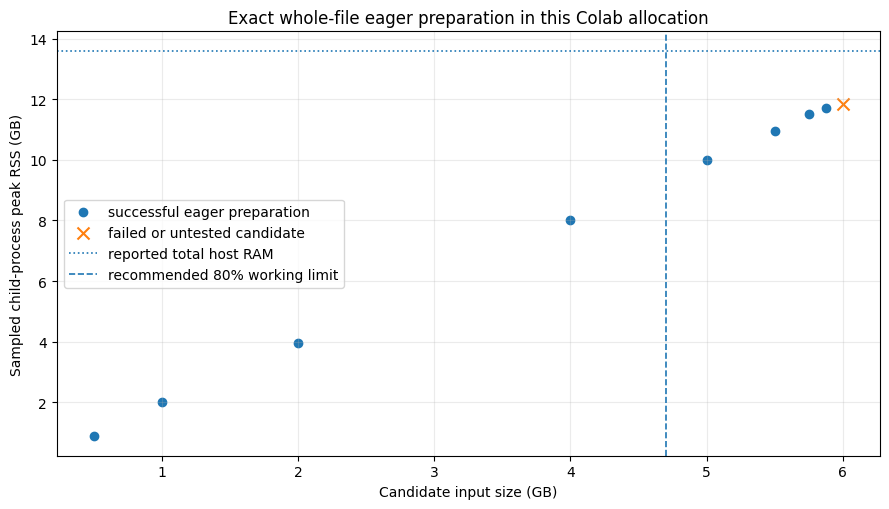

Saved plot: /content/drive/MyDrive/BOA_carbon_project/plots/colab_input_size_benchmark.png


In [10]:

plot_results = pd.read_csv(RESULTS_CSV)

plt.figure(figsize=(9, 5.2))

successful = plot_results[plot_results["success"].eq(True)]
failed = plot_results[plot_results["success"].eq(False)]

if len(successful):
    plt.scatter(
        successful["aligned_GB"],
        successful["parent_sampled_peak_child_rss_GB"],
        marker="o",
        label="successful eager preparation",
    )

if len(failed):
    plt.scatter(
        failed["aligned_GB"],
        failed["parent_sampled_peak_child_rss_GB"],
        marker="x",
        s=75,
        label="failed or untested candidate",
    )

plt.axhline(
    SNAPSHOT["ram_total_GB"],
    linestyle=":",
    linewidth=1.2,
    label="reported total host RAM",
)

if recommended_safe_eager_GB is not None:
    plt.axvline(
        recommended_safe_eager_GB,
        linestyle="--",
        linewidth=1.2,
        label="recommended 80% working limit",
    )

plt.xlabel("Candidate input size (GB)")
plt.ylabel("Sampled child-process peak RSS (GB)")
plt.title("Exact whole-file eager preparation in this Colab allocation")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=180)
plt.show()

print("Saved plot:", PLOT_PATH)



## Notes for the report and slides

Use wording of this form after running the notebook:

> Whole-file eager preparation succeeded up to **X GB** and first failed at **Y GB** in this
> particular Colab allocation. An 80% working limit of **Z GB** is retained to leave memory
> headroom. A complete memory-mapped/chunked scan was verified at **S GB**. The streaming result
> does not establish a universal BOA input maximum; full compression is additionally constrained by
> disk capacity, output space, measured compression throughput and Colab session duration.

Do **not** write:

> Colab cannot process files larger than 10 GB.

The benchmark is allocation-specific, and the eager-loading limit is not the same as the total size
that a memory-mapped compressor can stream.

### Relationship to the other notebooks

- Notebook 01 supplies the measured BOA compression throughput and CodeCarbon results.
- Notebook 02 supplies the input-size boundary and streaming-read lower bound.
- Notebook 03 reads the saved JSON files and performs the HDD/tape versus BOA calculations.


In [11]:

# Delete the temporary multi-gigabyte input unless explicitly retained.
if TILED_PATH.exists() and not KEEP_TILED_INPUT:
    temporary_size_GB = TILED_PATH.stat().st_size / 1e9
    TILED_PATH.unlink()
    print(f"Deleted temporary {temporary_size_GB:.3f} GB benchmark input: {TILED_PATH}")
elif TILED_PATH.exists():
    print("Retained temporary benchmark input:", TILED_PATH)


Deleted temporary 12.000 GB benchmark input: /content/boa_scaleup_repeated_cms_float32.bin
